# Assignment 15 - Core Algorithms, Metrics & Model Behavior

### Dataset
SuperStoreOrders.csv

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:
## Load Dataset

In [21]:
df = pd.read_csv("SuperStoreOrders.csv", encoding="unicode_escape")

df.head()
# Convert sales column to numeric

df["sales"] = df["sales"].str.replace(",", "")

df["sales"] = pd.to_numeric(df["sales"])

In [22]:
print("Shape :", df.shape)
print("\nColumns")
print(df.columns)
print("\nMissing Values")
print(df.isnull().sum())

Shape : (51290, 21)

Columns
Index(['ï»¿order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='str')

Missing Values
ï»¿order_id       0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64


In [7]:
### Observation is that the dataset contains both numerical and categorical columns. There are very few missing values, making it suitable for machine learning.

[  87.62218978   47.91324245   66.85258626   61.79298802  705.63074983
  237.93411553   61.08872603 1228.022507     10.53212532   95.76648764]


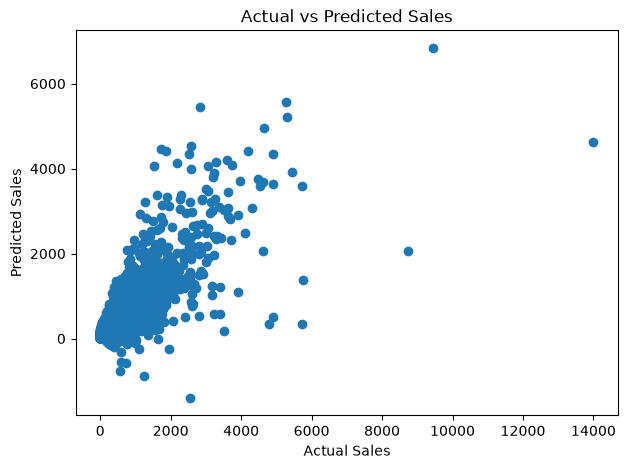

In [23]:
# Task 1 - Linear Regression
# Create input and output
features = df[["profit","quantity","discount","shipping_cost"]]
target = df["sales"]

x_train, x_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size = 0.2,
    random_state = 42
)
model = LinearRegression()

model.fit(x_train, y_train)
predictions = model.predict(x_test)
print(predictions[:10])

plt.figure(figsize=(7,5))
plt.scatter(y_test, predictions)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

In [9]:
### Observation is that thehe predicted values are close to the actual values for many samples. This indicates that the Linear Regression model has learned the relationship between the selected features and sales.

In [24]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 :", r2)

MAE : 118.61638801728698
MSE : 76103.26156180441
RMSE : 275.868195995487
R2 : 0.6889176029357487


In [12]:
### Interpretation

#MAE shows the average prediction error.
#MSE gives more weight to larger errors.
#RMSE represents the prediction error in the same unit as the target.
#R² Score shows how well the model explains the variation in sales. A higher value indicates better performance.

# Task 3 - Logistic Regression

In this task new target column is created based on the average sales. Orders with sales greater than the average are marked as **1 (High Sales)**, otherwise **0 (Low Sales)**.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

df["high_sales"] = (df["sales"] > df["sales"].mean()).astype(int)
features = df[["profit","quantity","discount","shipping_cost","category","segment","region"]]

target = df["high_sales"]
numeric_features = ["profit", "quantity", "discount", "shipping_cost"]
categorical_features = ["category", "segment", "region"]

preprocessor = ColumnTransformer(transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)])

x_train, x_test, y_train, y_test = train_test_split(features,target,test_size=0.2,random_state=42)

logistic_model = Pipeline([("preprocessor", preprocessor),("model", LogisticRegression(max_iter=1000))])
logistic_model.fit(x_train, y_train)
logistic_predictions = logistic_model.predict(x_test)

print("First 10 Predictions")
print(logistic_predictions[:10])

First 10 Predictions
[0 0 0 0 1 1 0 1 0 0]


### Observation found from this is that the Logistic Regression model successfully classifies whether an order belongs to the High Sales or Low Sales category.

In [31]:
# Task 4 - Naive Bayes Classifier
train_data = preprocessor.fit_transform(x_train)
test_data = preprocessor.transform(x_test)

naive_model = GaussianNB()
naive_model.fit(train_data, y_train)

naive_predictions = naive_model.predict(test_data)

print("First 10 Predictions")
print(naive_predictions[:10])
print("\nFirst 150 Predictions")
print(naive_predictions[:150])

First 10 Predictions
[0 0 0 0 1 1 0 1 0 0]

First 150 Predictions
[0 0 0 0 1 1 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1
 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 0
 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 1 1 1 0 1 1 1 0 0 0 0 1 0
 1 0 0 0 1 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 1 0
 0 0]


### Observation from this Naive Bayes is simple and fast. The predicted values can be compared with Logistic Regression in the next task using evaluation metrics.

In [27]:
# Task 5 - KNN
from sklearn.preprocessing import StandardScaler
numeric_train = x_train[numeric_features]
numeric_test = x_test[numeric_features]
scaler = StandardScaler()
numeric_train = scaler.fit_transform(numeric_train)
numeric_test = scaler.transform(numeric_test)
accuracy_list = {}

for k in [3, 5, 7]:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(numeric_train, y_train)
    predictions = knn_model.predict(numeric_test)

    accuracy = knn_model.score(numeric_test, y_test)
    accuracy_list[k] = accuracy
    print("K =", k)
    print("Accuracy =", accuracy)
    print()

best_k = max(accuracy_list, key=accuracy_list.get)
print("Best K Value :", best_k)

K = 3
Accuracy = 0.918795086761552

K = 5
Accuracy = 0.9206472996685514

K = 7
Accuracy = 0.9254240592708131

Best K Value : 7


### Observation from the three different K values were tested. The model with the highest accuracy is selected as the best K value for this dataset.

# Task 6 - Classification Metrics

In this task, the performance of Logistic Regression, Naive Bayes and KNN models is evaluated using different classification metrics

In [32]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Logistic Regression

logistic_accuracy = accuracy_score(y_test, logistic_predictions)
logistic_precision = precision_score(y_test, logistic_predictions)
logistic_recall = recall_score(y_test, logistic_predictions)
logistic_f1 = f1_score(y_test, logistic_predictions)

print("------------ Logistic Regression ------------")
print("Accuracy :", logistic_accuracy)
print("Precision :", logistic_precision)
print("Recall :", logistic_recall)
print("F1 Score :", logistic_f1)

print("\nClassification Report")
print(classification_report(y_test, logistic_predictions))

print("Confusion Matrix")
print(confusion_matrix(y_test, logistic_predictions))

# Naive Bayes

naive_accuracy = accuracy_score(y_test, naive_predictions)
naive_precision = precision_score(y_test, naive_predictions)
naive_recall = recall_score(y_test, naive_predictions)
naive_f1 = f1_score(y_test, naive_predictions)

print("\n------------ Naive Bayes ------------")
print("Accuracy :", naive_accuracy)
print("Precision :", naive_precision)
print("Recall :", naive_recall)
print("F1 Score :", naive_f1)

print("\nClassification Report")
print(classification_report(y_test, naive_predictions))

print("Confusion Matrix")
print(confusion_matrix(y_test, naive_predictions))

# KNN

knn_model = KNeighborsClassifier(n_neighbors = best_k)

knn_model.fit(numeric_train, y_train)

knn_predictions = knn_model.predict(numeric_test)

knn_accuracy = accuracy_score(y_test, knn_predictions)
knn_precision = precision_score(y_test, knn_predictions)
knn_recall = recall_score(y_test, knn_predictions)
knn_f1 = f1_score(y_test, knn_predictions)

print("\n------------ KNN ------------")
print("Accuracy :", knn_accuracy)
print("Precision :", knn_precision)
print("Recall :", knn_recall)
print("F1 Score :", knn_f1)

print("\nClassification Report")
print(classification_report(y_test, knn_predictions))

print("Confusion Matrix")
print(confusion_matrix(y_test, knn_predictions))


print("\n------------ Accuracy Comparison ------------")
print("Logistic Regression :", logistic_accuracy)
print("Naive Bayes :", naive_accuracy)
print("KNN :", knn_accuracy)

------------ Logistic Regression ------------
Accuracy : 0.9093390524468707
Precision : 0.8746690203000883
Recall : 0.754185692541857
F1 Score : 0.809971393543114

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      7630
           1       0.87      0.75      0.81      2628

    accuracy                           0.91     10258
   macro avg       0.90      0.86      0.88     10258
weighted avg       0.91      0.91      0.91     10258

Confusion Matrix
[[7346  284]
 [ 646 1982]]

------------ Naive Bayes ------------
Accuracy : 0.9079742639890817
Precision : 0.8199088145896657
Recall : 0.8211567732115678
F1 Score : 0.820532319391635

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      7630
           1       0.82      0.82      0.82      2628

    accuracy                           0.91     10258
   macro avg       0.88      0.88      0.88  

### Observation from qll three classification models were evaluated using Accuracy, Precision, Recall and F1 Score. The Classification Report and Confusion Matrix provide detailed information about each model's performance. The model with the highest accuracy performs better for this dataset.

In [33]:
# Task 7 - Overfitting & Underfitting
from sklearn.metrics import accuracy_score

# Underfitting Model
underfit_model = KNeighborsClassifier(n_neighbors=25)
underfit_model.fit(numeric_train, y_train)
train_prediction = underfit_model.predict(numeric_train)
test_prediction = underfit_model.predict(numeric_test)

print("Underfitting Model")
print("Training Accuracy :", accuracy_score(y_train, train_prediction))
print("Testing Accuracy :", accuracy_score(y_test, test_prediction))

# Overfitting Model
overfit_model = KNeighborsClassifier(n_neighbors=1)
overfit_model.fit(numeric_train, y_train)

train_prediction = overfit_model.predict(numeric_train)
test_prediction = overfit_model.predict(numeric_test)

print("\nOverfitting Model")
print("Training Accuracy :", accuracy_score(y_train, train_prediction))
print("Testing Accuracy :", accuracy_score(y_test, test_prediction))

Underfitting Model
Training Accuracy : 0.9315899785533243
Testing Accuracy : 0.9269838175082862

Overfitting Model
Training Accuracy : 1.0
Testing Accuracy : 0.9106063560148177


Task 8 - Bias & Variance
Question 1:
Bias is the error caused when a model is too simple to learn the patterns in the data. High bias usually leads to underfitting.

Question 2:
Variance is the error caused when a model learns the training data too closely. High variance usually leads to overfitting.

Question 3:
- High Bias → Underfitting
- High Variance → Overfitting


Question 4:
- Use more training data.
- Remove unnecessary features.
- Choose a suitable model complexity.
- Use cross-validation and apply regularization techniques when required.

# conclusion from this assignmentis that  I learned how to build regression and classification models using Scikit-learn. I also understood how different evaluation metrics help measure model performance and how model complexity affects underfitting and overfitting, this assignment helped me understand the complete workflow from training a model to evaluating its performance